# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from skimage import data

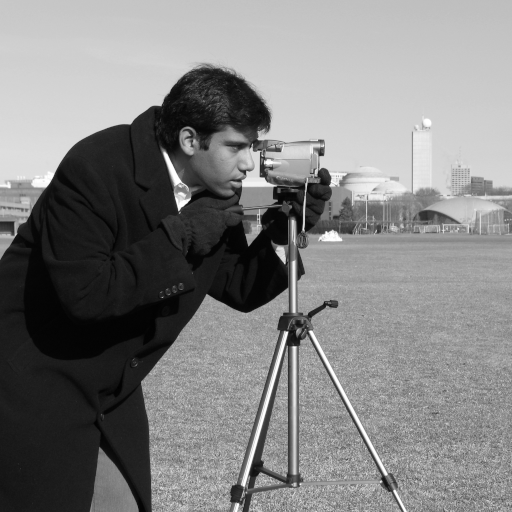

In [2]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera())
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image

# scaling factors
width, height = img.size

cx = 2
cy = 2

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

new_width = int(width * cx)
new_height = int(height * cy)

scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)


Original size: (512, 512)
Scaled size: (1024, 1024)


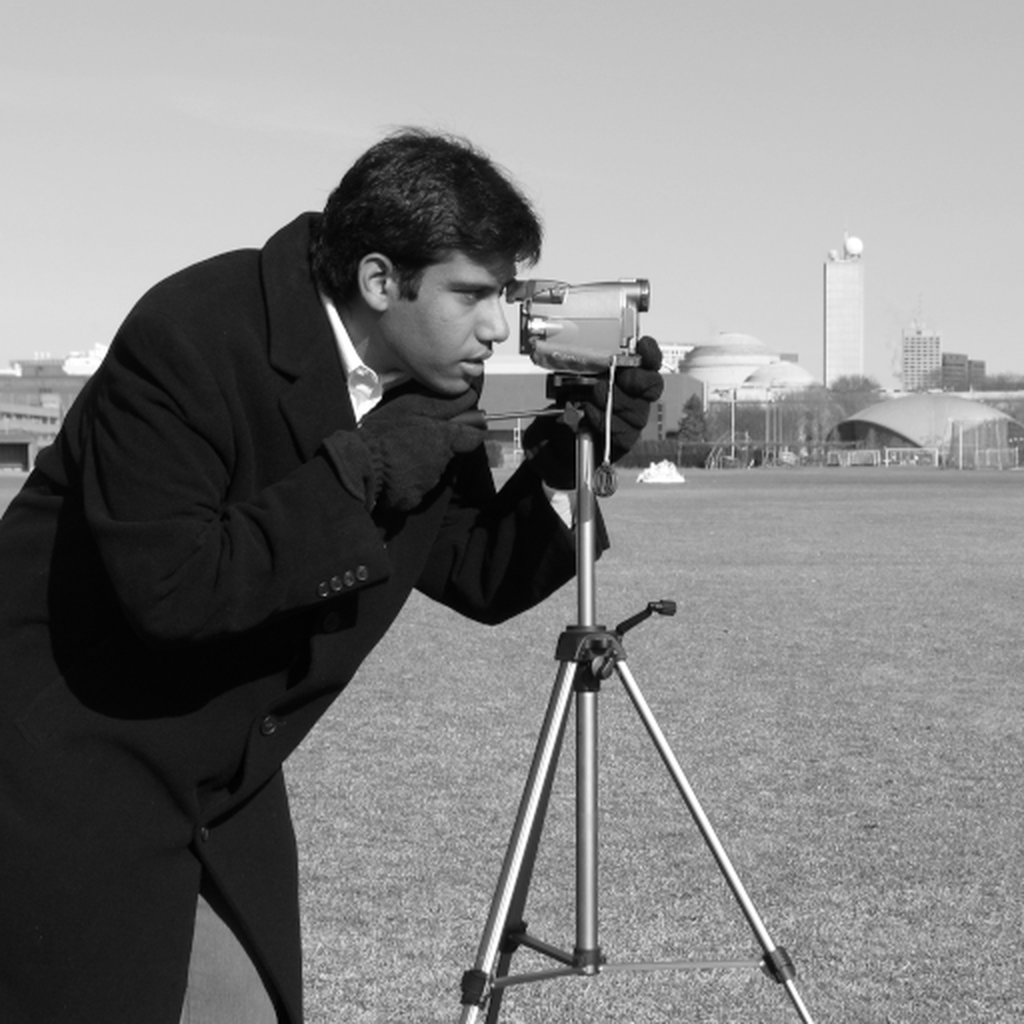

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)
scaled_img

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

In [7]:
non_uniform_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Non-uniform size: (1024, 512)


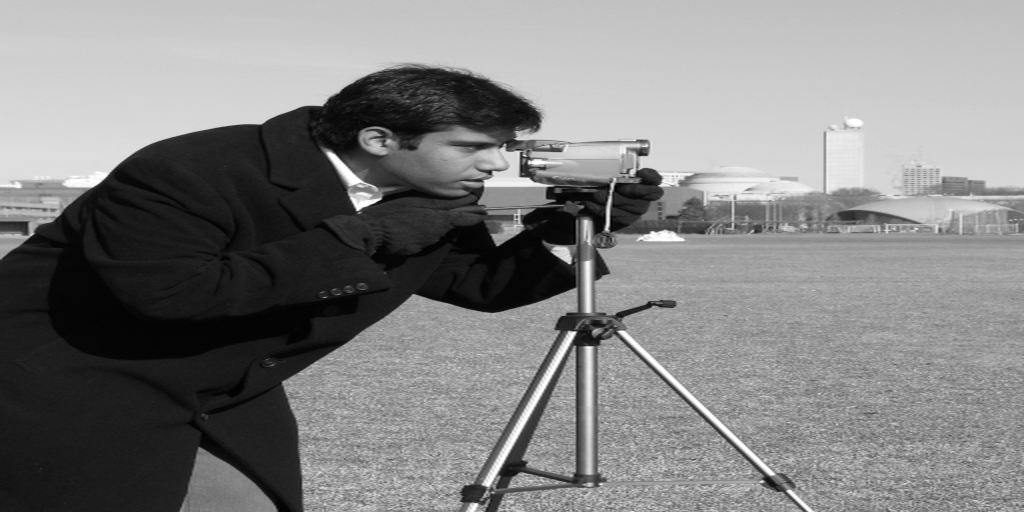

In [8]:
non_uniform_img.save("task1_1_non_uniform.jpg")

print("Original size:", img.size)
print("Non-uniform size:", non_uniform_img.size)
non_uniform_img

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


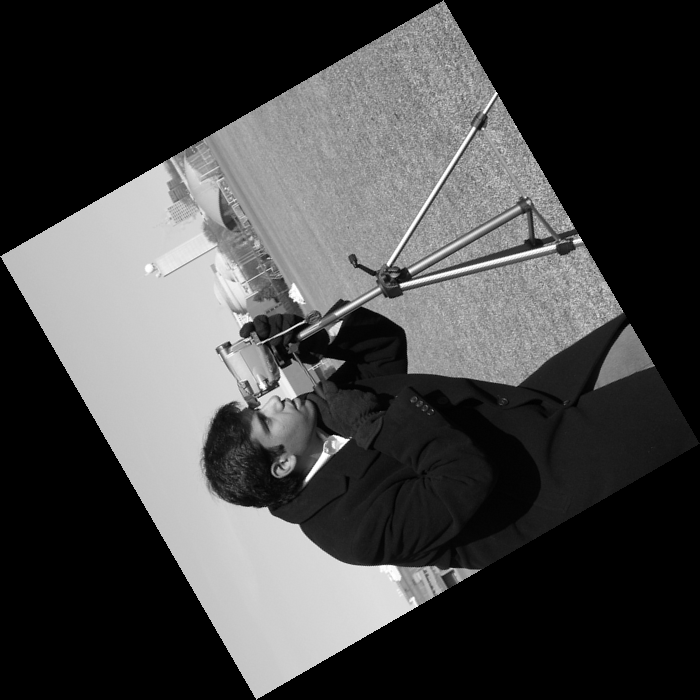

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
rotated_img

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
sh = 0.5

shx = sh
shy = 0

new_width = int(width + abs(shx * height))
new_height = height

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

Original size: (512, 512)
Sheared size: (768, 512)


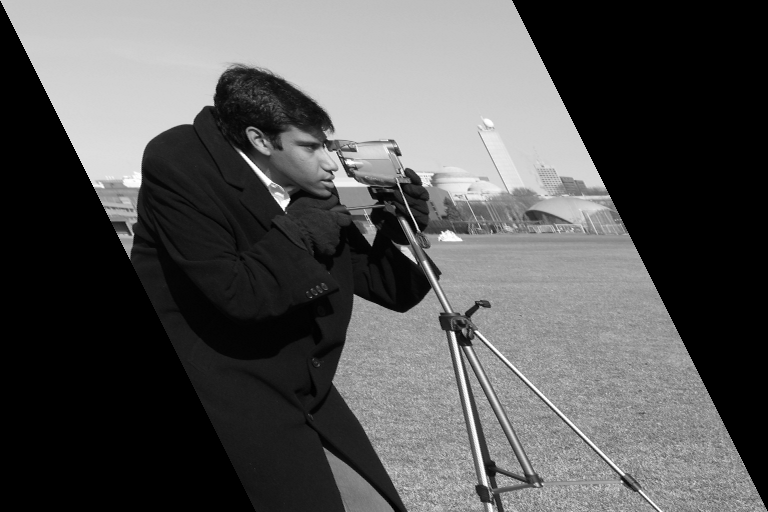

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)
sheared_img

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

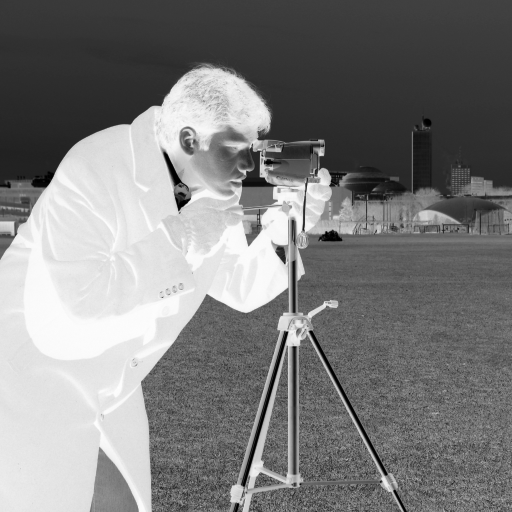

In [14]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr.astype(np.uint8))

negative_img.save("negative_numpy.jpg")

negative_img

In [15]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

negative_pil.save("negative_pil.jpg")

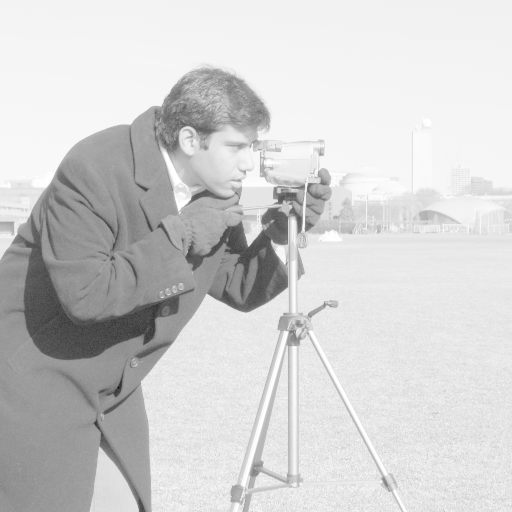

In [16]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
arr = np.array(img, dtype=np.float32)

c = 255 / np.log(1 + 255)

log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.clip(log_transformed_arr, 0, 255)

log_img = Image.fromarray(log_transformed_arr.astype(np.uint8))

log_img.save("log_transformed.jpg")
log_img

Gamma = 1


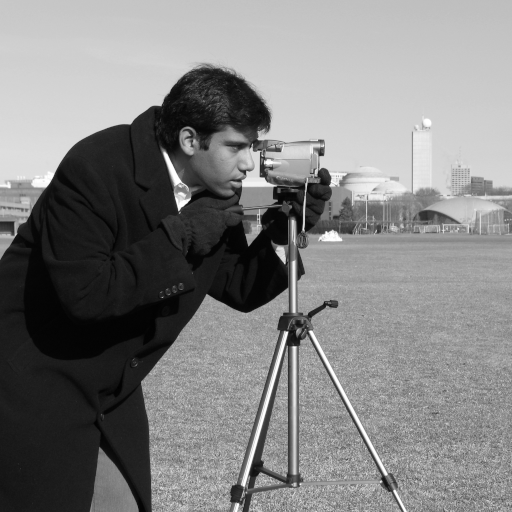

Gamma = 0.5


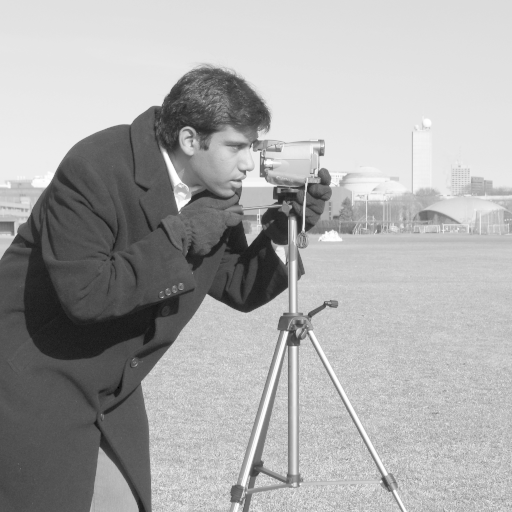

Gamma = 0.2


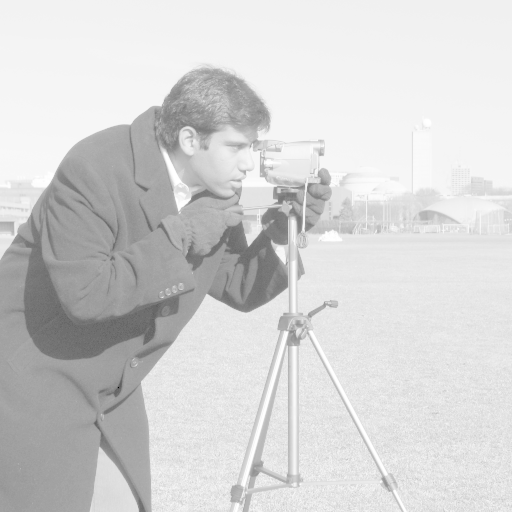

In [17]:

# ── 3. Power-law / Gamma correction ───────────────
gammas = [1, 0.5, 0.2]

for gamma in gammas:
    normalized = np.array(img, dtype=np.float32) / 255.0

    gamma_transformed = 255 * (normalized ** gamma)

    gamma_img = Image.fromarray(gamma_transformed.astype(np.uint8))

    print("Gamma =", gamma)
    display(gamma_img)